# DAAN 545 — Frequent Pattern / Association Rule Mining

**Goal (P1):** Turn the cleaned delay panel into many **binary items**, then run `apriori`, `fpgrowth`, and `association_rules` from **mlxtend**.

**Input:** `data/processed/airline_delay_cause_with_airports.csv` (BTS delays + OpenFlights geography).

**Approach:**
1. Discretize continuous fields with inequalities (e.g. `pct_delayed >= Q75`)
2. One-hot categoricals (`census_region`, `tz_group`, top carriers/airports)
3. Mine frequent itemsets with apriori **and** fpgrowth
4. Generate association rules; vary `min_support` and discuss patterns


## 0. Setup

Helpers live in `src/association_rules.py` (`build_transaction_matrix`) so the same binary encoding can be reused later.


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent

DATA_PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.association_rules import build_transaction_matrix

print(f"Project root: {ROOT}")


Project root: c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis


## 1. Load enriched panel

Same monthly grain as EDA: **carrier × airport × year × month**.


In [2]:
PANEL_PATH = DATA_PROCESSED / "airline_delay_cause_with_airports.csv"
df = pd.read_csv(PANEL_PATH)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns from {PANEL_PATH.name}")
df.head(3)


Loaded 8,963 rows × 38 columns from airline_delay_cause_with_airports.csv


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,of_city,of_country,lat,lon,altitude_ft,timezone_offset,tz,tz_group,state,census_region
0,2026,6,MQ,Envoy Air,MSP,"Minneapolis, MN: Minneapolis-St Paul International",85.0000,11.0000,1.6300,0.7000,...,Minneapolis,United States,44.8820,-93.2218,841,-6.0000,America/Chicago,Central,MN,Midwest
1,2026,6,MQ,Envoy Air,ORD,"Chicago, IL: Chicago O'Hare International","4,737.0000",926.0000,188.1100,101.8800,...,Chicago,United States,41.9786,-87.9048,672,-6.0000,America/Chicago,Central,IL,Midwest
2,2026,6,MQ,Envoy Air,PHX,"Phoenix, AZ: Phoenix Sky Harbor International","1,035.0000",168.0000,58.1500,3.8700,...,Phoenix,United States,33.4343,-112.0120,1135,-7.0000,America/Phoenix,Mountain,AZ,West


## 2. Create binary / one-hot / discretized items

| Kind | Examples |
|------|----------|
| Discretize | `high_delay` (pct_delayed ≥ Q75), `high_cancel`, `*_dominant` cause shares ≥ 35% |
| Season | `is_winter`, `is_spring`, `is_summer`, `is_fall` |
| One-hot | `region_*`, `tz_*`, top carriers / airports |
| Geography | `high_altitude` (≥ 3000 ft), `northern` (lat ≥ median) |

These are the “baskets”: each row is a transaction; each `True` column is an item in that basket.


In [3]:
binary, meta = build_transaction_matrix(df)

print("=== Binary matrix ===")
print(f"Rows (transactions): {meta['n_rows']:,}")
print(f"Items (binary columns): {meta['n_items']}")
print(f"high_delay cutoff (Q{meta['delay_q']:.2f}): {meta['delay_cut_pct']:.2f}% delayed")
print(f"high_cancel cutoff (Q{meta['cancel_q']:.2f}): {meta['cancel_cut_pct']:.2f}% cancelled")
print(f"Cause-dominant share threshold: {meta['cause_share_threshold']:.0%}")
print(f"High-altitude cutoff: {meta['high_altitude_ft']:.0f} ft")
print(f"Northern lat median: {meta['lat_median']:.2f}")

print("\nItem support (fraction of rows = True):")
display(meta["item_support"].to_frame("support"))

# Persist for the report / teammates
out_bin = DATA_PROCESSED / "association_binary_matrix.csv"
binary.astype(int).to_csv(out_bin, index=False)
print(f"\nSaved binary matrix → {out_bin}")
binary.head()


=== Binary matrix ===
Rows (transactions): 8,963
Items (binary columns): 41
high_delay cutoff (Q0.75): 28.22% delayed
high_cancel cutoff (Q0.75): 2.27% cancelled
Cause-dominant share threshold: 35%
High-altitude cutoff: 3000 ft
Northern lat median: 38.85

Item support (fraction of rows = True):


,support
late_aircraft_dominant,0.5411
northern,0.5009
tz_Eastern,0.4991
region_South,0.4436
carrier_dominant,0.3710
is_summer,0.2807
region_West,0.2534
high_cancel,0.2500
high_delay,0.2500
tz_Central,0.2476



Saved binary matrix → c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\data\processed\association_binary_matrix.csv


,high_delay,high_cancel,carrier_dominant,weather_dominant,nas_dominant,security_dominant,late_aircraft_dominant,is_winter,is_spring,is_summer,...,airport_DEN,airport_DFW,airport_EWR,airport_JFK,airport_LAX,airport_LGA,airport_MIA,airport_ORD,airport_SEA,airport_SFO
0,False,False,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## 3. Frequent itemsets — apriori vs fpgrowth

Both algorithms find the same frequent itemsets for a given `min_support` (on boolean data). We run **both** as required, then compare counts / top patterns.

Start with `min_support=0.05` (itemset in ≥5% of rows).


In [4]:
MIN_SUPPORT = 0.05

freq_apriori = apriori(binary, min_support=MIN_SUPPORT, use_colnames=True)
freq_apriori["length"] = freq_apriori["itemsets"].apply(len)
freq_apriori = freq_apriori.sort_values("support", ascending=False).reset_index(drop=True)

freq_fp = fpgrowth(binary, min_support=MIN_SUPPORT, use_colnames=True)
freq_fp["length"] = freq_fp["itemsets"].apply(len)
freq_fp = freq_fp.sort_values("support", ascending=False).reset_index(drop=True)

print(f"min_support = {MIN_SUPPORT}")
print(f"Apriori itemsets:  {len(freq_apriori):,}")
print(f"FP-Growth itemsets:{len(freq_fp):,}")
print(f"Same itemset count: {len(freq_apriori) == len(freq_fp)}")

# Set equality check (order-independent)
set_a = set(frozenset(s) for s in freq_apriori["itemsets"])
set_f = set(frozenset(s) for s in freq_fp["itemsets"])
print(f"Identical itemset collections: {set_a == set_f}")

print("\nTop 15 apriori itemsets:")
display(freq_apriori.head(15))
print("Top multi-item FP-Growth itemsets (length ≥ 2):")
display(freq_fp.query("length >= 2").head(15))


min_support = 0.05
Apriori itemsets:  212
FP-Growth itemsets:212
Same itemset count: True
Identical itemset collections: True

Top 15 apriori itemsets:


,support,itemsets,length
0,0.5411,frozenset({late_aircraft_dominant}),1
1,0.5009,frozenset({northern}),1
2,0.4991,frozenset({tz_Eastern}),1
3,0.4436,frozenset({region_South}),1
4,0.3710,frozenset({carrier_dominant}),1
5,0.3144,"frozenset({northern, tz_Eastern})",2
6,0.2906,"frozenset({tz_Eastern, region_South})",2
7,0.2807,frozenset({is_summer}),1
8,0.2735,"frozenset({tz_Eastern, late_aircraft_dominant})",2
9,0.2652,"frozenset({northern, late_aircraft_dominant})",2


Top multi-item FP-Growth itemsets (length ≥ 2):


,support,itemsets,length
5,0.3144,"frozenset({northern, tz_Eastern})",2
6,0.2906,"frozenset({tz_Eastern, region_South})",2
8,0.2735,"frozenset({tz_Eastern, late_aircraft_dominant})",2
9,0.2652,"frozenset({northern, late_aircraft_dominant})",2
10,0.2538,"frozenset({region_South, late_aircraft_dominant})",2
19,0.1843,"frozenset({northern, carrier_dominant})",2
20,0.1743,"frozenset({tz_Eastern, region_South, late_aircraft_dominant})",3
21,0.1678,"frozenset({tz_Eastern, carrier_dominant})",2
22,0.1642,"frozenset({region_Northeast, tz_Eastern})",2
24,0.1642,"frozenset({region_Northeast, northern})",2


## 4. Association rules

Generate rules from the FP-Growth itemsets (same as apriori here). Focus on **lift > 1** (positive association) and readable antecedents/consequents involving delay outcomes.


In [5]:
MIN_CONFIDENCE = 0.30

rules = association_rules(freq_fp, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules["antecedent_len"] = rules["antecedents"].apply(len)
rules["consequent_len"] = rules["consequents"].apply(len)
rules = rules.sort_values(["lift", "confidence"], ascending=False).reset_index(drop=True)

print(f"Rules with confidence ≥ {MIN_CONFIDENCE}: {len(rules):,}")
print(f"Rules with lift > 1: {(rules['lift'] > 1).sum():,}")

# Prefer rules that say something about delays / causes
delay_like = {"high_delay", "high_cancel", "weather_dominant", "carrier_dominant",
              "nas_dominant", "late_aircraft_dominant", "security_dominant"}
mask_delay = rules["consequents"].apply(lambda s: bool(set(s) & delay_like)) | rules[
    "antecedents"
].apply(lambda s: bool(set(s) & delay_like))
rules_delay = rules.loc[mask_delay].copy()

print(f"Rules touching a delay/cause item: {len(rules_delay):,}")
display(
    rules_delay[
        ["antecedents", "consequents", "support", "confidence", "lift", "leverage", "conviction"]
    ].head(20)
)

rules_path = DATA_PROCESSED / "association_rules_min_support_0_05.csv"
# frozensets → readable strings for CSV
export = rules_delay.copy()
export["antecedents"] = export["antecedents"].apply(lambda s: ", ".join(sorted(s)))
export["consequents"] = export["consequents"].apply(lambda s: ", ".join(sorted(s)))
export.to_csv(rules_path, index=False)
print(f"Saved delay-related rules → {rules_path}")


Rules with confidence ≥ 0.3: 422
Rules with lift > 1: 360
Rules touching a delay/cause item: 322


,antecedents,consequents,support,confidence,lift,leverage,conviction
23,"frozenset({northern, tz_Central, late_aircraft_dominant})",frozenset({region_Midwest}),0.0525,1.0000,7.2050,0.0453,inf
25,frozenset({region_Midwest}),"frozenset({northern, tz_Central, late_aircraft_dominant})",0.0525,0.3786,7.2050,0.0453,1.5247
28,"frozenset({region_Midwest, late_aircraft_dominant})","frozenset({northern, tz_Central})",0.0525,0.6382,6.7456,0.0448,2.5025
29,"frozenset({northern, tz_Central})","frozenset({region_Midwest, late_aircraft_dominant})",0.0525,0.5554,6.7456,0.0448,2.0641
30,"frozenset({nas_dominant, northern, tz_Eastern})",frozenset({region_Northeast}),0.0572,0.6970,4.2441,0.0437,2.7584
31,frozenset({region_Northeast}),"frozenset({nas_dominant, northern, tz_Eastern})",0.0572,0.3485,4.2441,0.0437,1.4089
32,frozenset({tz_Mountain}),"frozenset({region_West, late_aircraft_dominant})",0.0531,0.5440,4.0131,0.0399,1.8957
33,"frozenset({region_West, late_aircraft_dominant})",frozenset({tz_Mountain}),0.0531,0.3918,4.0131,0.0399,1.4836
36,"frozenset({tz_Pacific, late_aircraft_dominant})",frozenset({region_West}),0.0825,1.0000,3.9467,0.0616,inf
37,"frozenset({tz_Pacific, carrier_dominant})",frozenset({region_West}),0.0623,1.0000,3.9467,0.0465,inf


Saved delay-related rules → c:\Users\MLMir\Projects\DAAN545-flight-delay-analysis\data\processed\association_rules_min_support_0_05.csv


## 5. Vary `min_support`

How many itemsets / rules survive as we raise the bar? Lower support → more (noisier) patterns; higher → fewer, more common patterns.


,min_support,n_itemsets,n_rules_conf>=0.30,n_delay_related_rules
0,0.0200,756,2021,1508
1,0.0500,212,422,322
2,0.0800,96,140,90
3,0.1000,69,85,51
4,0.1500,33,45,27


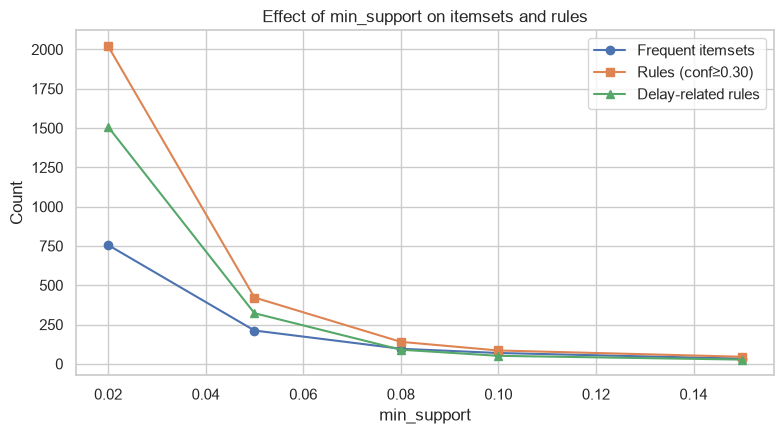

In [6]:
supports = [0.02, 0.05, 0.08, 0.10, 0.15]
sweep_rows = []
for s in supports:
    fi = fpgrowth(binary, min_support=s, use_colnames=True)
    if fi.empty:
        n_rules = 0
        n_delay_rules = 0
    else:
        r = association_rules(fi, metric="confidence", min_threshold=MIN_CONFIDENCE)
        n_rules = len(r)
        if n_rules:
            n_delay_rules = int(
                (
                    r["consequents"].apply(lambda x: bool(set(x) & delay_like))
                    | r["antecedents"].apply(lambda x: bool(set(x) & delay_like))
                ).sum()
            )
        else:
            n_delay_rules = 0
    sweep_rows.append(
        {
            "min_support": s,
            "n_itemsets": len(fi),
            "n_rules_conf>=0.30": n_rules,
            "n_delay_related_rules": n_delay_rules,
        }
    )

sweep = pd.DataFrame(sweep_rows)
display(sweep)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sweep["min_support"], sweep["n_itemsets"], marker="o", label="Frequent itemsets")
ax.plot(sweep["min_support"], sweep["n_rules_conf>=0.30"], marker="s", label="Rules (conf≥0.30)")
ax.plot(sweep["min_support"], sweep["n_delay_related_rules"], marker="^", label="Delay-related rules")
ax.set_xlabel("min_support")
ax.set_ylabel("Count")
ax.set_title("Effect of min_support on itemsets and rules")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "09_arm_minsupport_sweep.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Discussion prompts (for the P1 writeup)

Use outputs above; rewrite in your own words:

1. **Interesting patterns** — Which antecedents most often lift `high_delay`, `weather_dominant`, or `late_aircraft_dominant`? Do region / season / altitude show up?
2. **min_support tradeoff** — What happens to rule count as support rises from 0.02 → 0.15? Which support would you defend for the report?
3. **Apriori vs FP-Growth** — Same itemsets here; note runtime/scalability difference for larger baskets.
4. **Strategic insight** — e.g. if `is_summer` + certain hubs associate with `high_delay`, that supports seasonal ops staffing; if `weather_dominant` ties to `northern` / winter, that foreshadows a weather-data join.
5. **Limits** — Monthly aggregates blur day-level storms; one-hots for only top carriers/airports miss smaller players; thresholds (Q75, 35% share) are choices — sensitivity matters.


In [7]:
# Compact “report-ready” snapshot
top_lift = rules_delay.head(8).copy()
top_lift["antecedents"] = top_lift["antecedents"].apply(lambda s: ", ".join(sorted(s)))
top_lift["consequents"] = top_lift["consequents"].apply(lambda s: ", ".join(sorted(s)))

print("=== Draft ARM insights (edit for your report) ===\n")
print(f"1. Built {meta['n_items']} binary items on {meta['n_rows']:,} monthly transactions.")
print(f"2. At min_support={MIN_SUPPORT}, apriori and fpgrowth found {len(freq_fp):,} itemsets (identical sets).")
print(f"3. association_rules produced {len(rules):,} rules (confidence≥{MIN_CONFIDENCE}); "
      f"{len(rules_delay):,} touch a delay/cause item.")
print("4. Highest-lift delay-related rules:")
for _, row in top_lift.iterrows():
    print(
        f"   - {{{row['antecedents']}}} => {{{row['consequents']}}} "
        f"(support={row['support']:.3f}, conf={row['confidence']:.3f}, lift={row['lift']:.2f})"
    )
print("5. min_support sweep:")
for _, row in sweep.iterrows():
    print(
        f"   - support={row['min_support']:.2f}: "
        f"{int(row['n_itemsets']):,} itemsets, "
        f"{int(row['n_delay_related_rules']):,} delay-related rules"
    )


=== Draft ARM insights (edit for your report) ===

1. Built 41 binary items on 8,963 monthly transactions.
2. At min_support=0.05, apriori and fpgrowth found 212 itemsets (identical sets).
3. association_rules produced 422 rules (confidence≥0.3); 322 touch a delay/cause item.
4. Highest-lift delay-related rules:
   - {late_aircraft_dominant, northern, tz_Central} => {region_Midwest} (support=0.053, conf=1.000, lift=7.20)
   - {region_Midwest} => {late_aircraft_dominant, northern, tz_Central} (support=0.053, conf=0.379, lift=7.20)
   - {late_aircraft_dominant, region_Midwest} => {northern, tz_Central} (support=0.053, conf=0.638, lift=6.75)
   - {northern, tz_Central} => {late_aircraft_dominant, region_Midwest} (support=0.053, conf=0.555, lift=6.75)
   - {nas_dominant, northern, tz_Eastern} => {region_Northeast} (support=0.057, conf=0.697, lift=4.24)
   - {region_Northeast} => {nas_dominant, northern, tz_Eastern} (support=0.057, conf=0.349, lift=4.24)
   - {tz_Mountain} => {late_aircraft

## 7. Reproducibility

- [ ] `pip install -r requirements.txt` (includes `mlxtend`)
- [ ] Enriched panel present: `data/processed/airline_delay_cause_with_airports.csv`
- [ ] Run this notebook top-to-bottom
- [ ] Figures: `reports/figures/09_arm_minsupport_sweep.png`
- [ ] Exports: `association_binary_matrix.csv`, `association_rules_min_support_0_05.csv`
- [ ] Writeup covers binary encoding, both miners, rules, and min_support sensitivity
